In [ ]:
import os

# Tự động detect môi trường
if os.path.exists('/kaggle/input'):
    ENV = 'kaggle'
    train_dir = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
    valid_dir = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

elif os.path.exists('/content'):
    ENV = 'colab'
    os.environ['KAGGLE_USERNAME'] = "username"
    os.environ['KAGGLE_KEY'] = "key"
    !kaggle datasets download -d vipoooool/new-plant-diseases-dataset
    !unzip -q new-plant-diseases-dataset.zip -d dataset
    train_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
    valid_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'

else:
    ENV = 'local'
    train_dir = 'data/raw/train'
    valid_dir = 'data/raw/valid'

if ENV == 'kaggle':
    output_dir = '/kaggle/working'
elif ENV == 'colab':
    output_dir = '/content'
else:
    output_dir = 'assets'

print(f"Môi trường: {ENV}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load data - KHÔNG rescale vì EfficientNet tự xử lý
train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2]
)

valid_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes
print(f"Số class: {NUM_CLASSES}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Số class: 38


In [6]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)
print("Xây model xong!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Xây model xong!


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    f'{output_dir}/efficientnet_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("Train xong!")

Epoch 1/10
1869/2197 ━━━━━━━━━━━━━━━━━━━━ 2:57 543ms/step - accuracy: 0.8340 - loss: 0.5504

2026-05-26 01:16:52.518259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:16:52.659817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:16:52.993641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:16:53.134433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:16:53.904691: E external/local_xla/xla/stream_

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8381 - loss: 0.5354

2026-05-26 01:22:10.841461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:22:10.976705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:22:11.285452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:22:11.425647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 01:22:11.566561: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.94383, saving model to /kaggle/working/efficientnet_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1366s 613ms/step - accuracy: 0.8381 - loss: 0.5354 - val_accuracy: 0.9438 - val_loss: 0.1638 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8963 - loss: 0.3298
Epoch 2: val_accuracy improved from 0.94383 to 0.94582, saving model to /kaggle/working/efficientnet_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1030s 469ms/step - accuracy: 0.8963 - loss: 0.3297 - val_accuracy: 0.9458 - val_loss: 0.1592 - learning_rate: 0.0010
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9106 - loss: 0.2871
Epoch 3: val_accuracy improved from 0.94582 to 0.95652, saving model to /kaggle/working/efficientnet_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1034s 471ms/step - accuracy: 0.9106 - loss: 0.2871 - val_accuracy: 0.9565 - val_loss: 0.1302 - learning_rate: 0.0010
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 

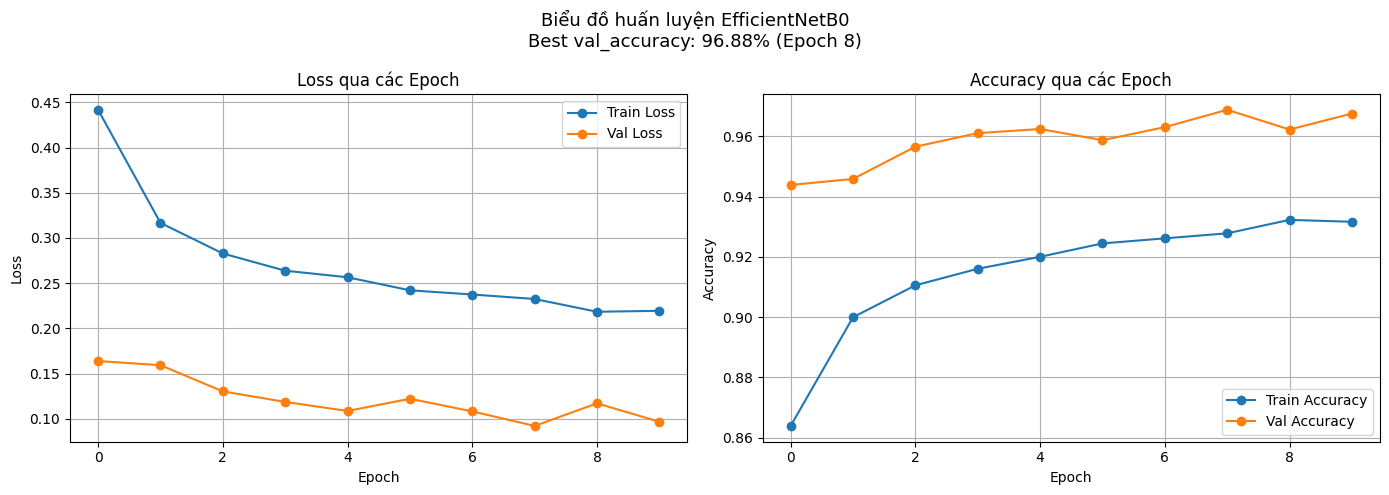

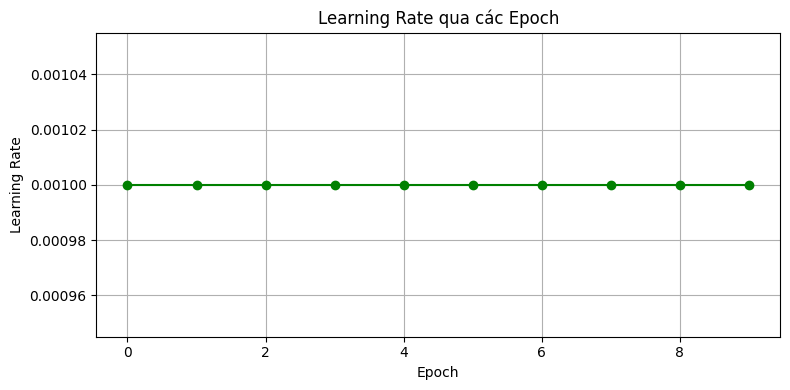

Đã lưu biểu đồ vào /kaggle/working/


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Loss
axes[0].plot(history.history['loss'], marker='o', label='Train Loss')
axes[0].plot(history.history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Loss qua các Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Biểu đồ Accuracy
axes[1].plot(history.history['accuracy'], marker='o', label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], marker='o', label='Val Accuracy')
axes[1].set_title('Accuracy qua các Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Biểu đồ huấn luyện EfficientNetB0\nBest val_accuracy: 96.88% (Epoch 8)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{output_dir}/training_history_efficientnet.png')
plt.show()

# Biểu đồ Learning Rate
plt.figure(figsize=(8, 4))
plt.plot(history.history['learning_rate'], marker='o', color='green')
plt.title('Learning Rate qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/learning_rate.png')
plt.show()

print("Đã lưu biểu đồ vào /kaggle/working/")

Found 17572 images belonging to 38 classes.
Đang dự đoán...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


550/550 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step
Accuracy: 96.88%


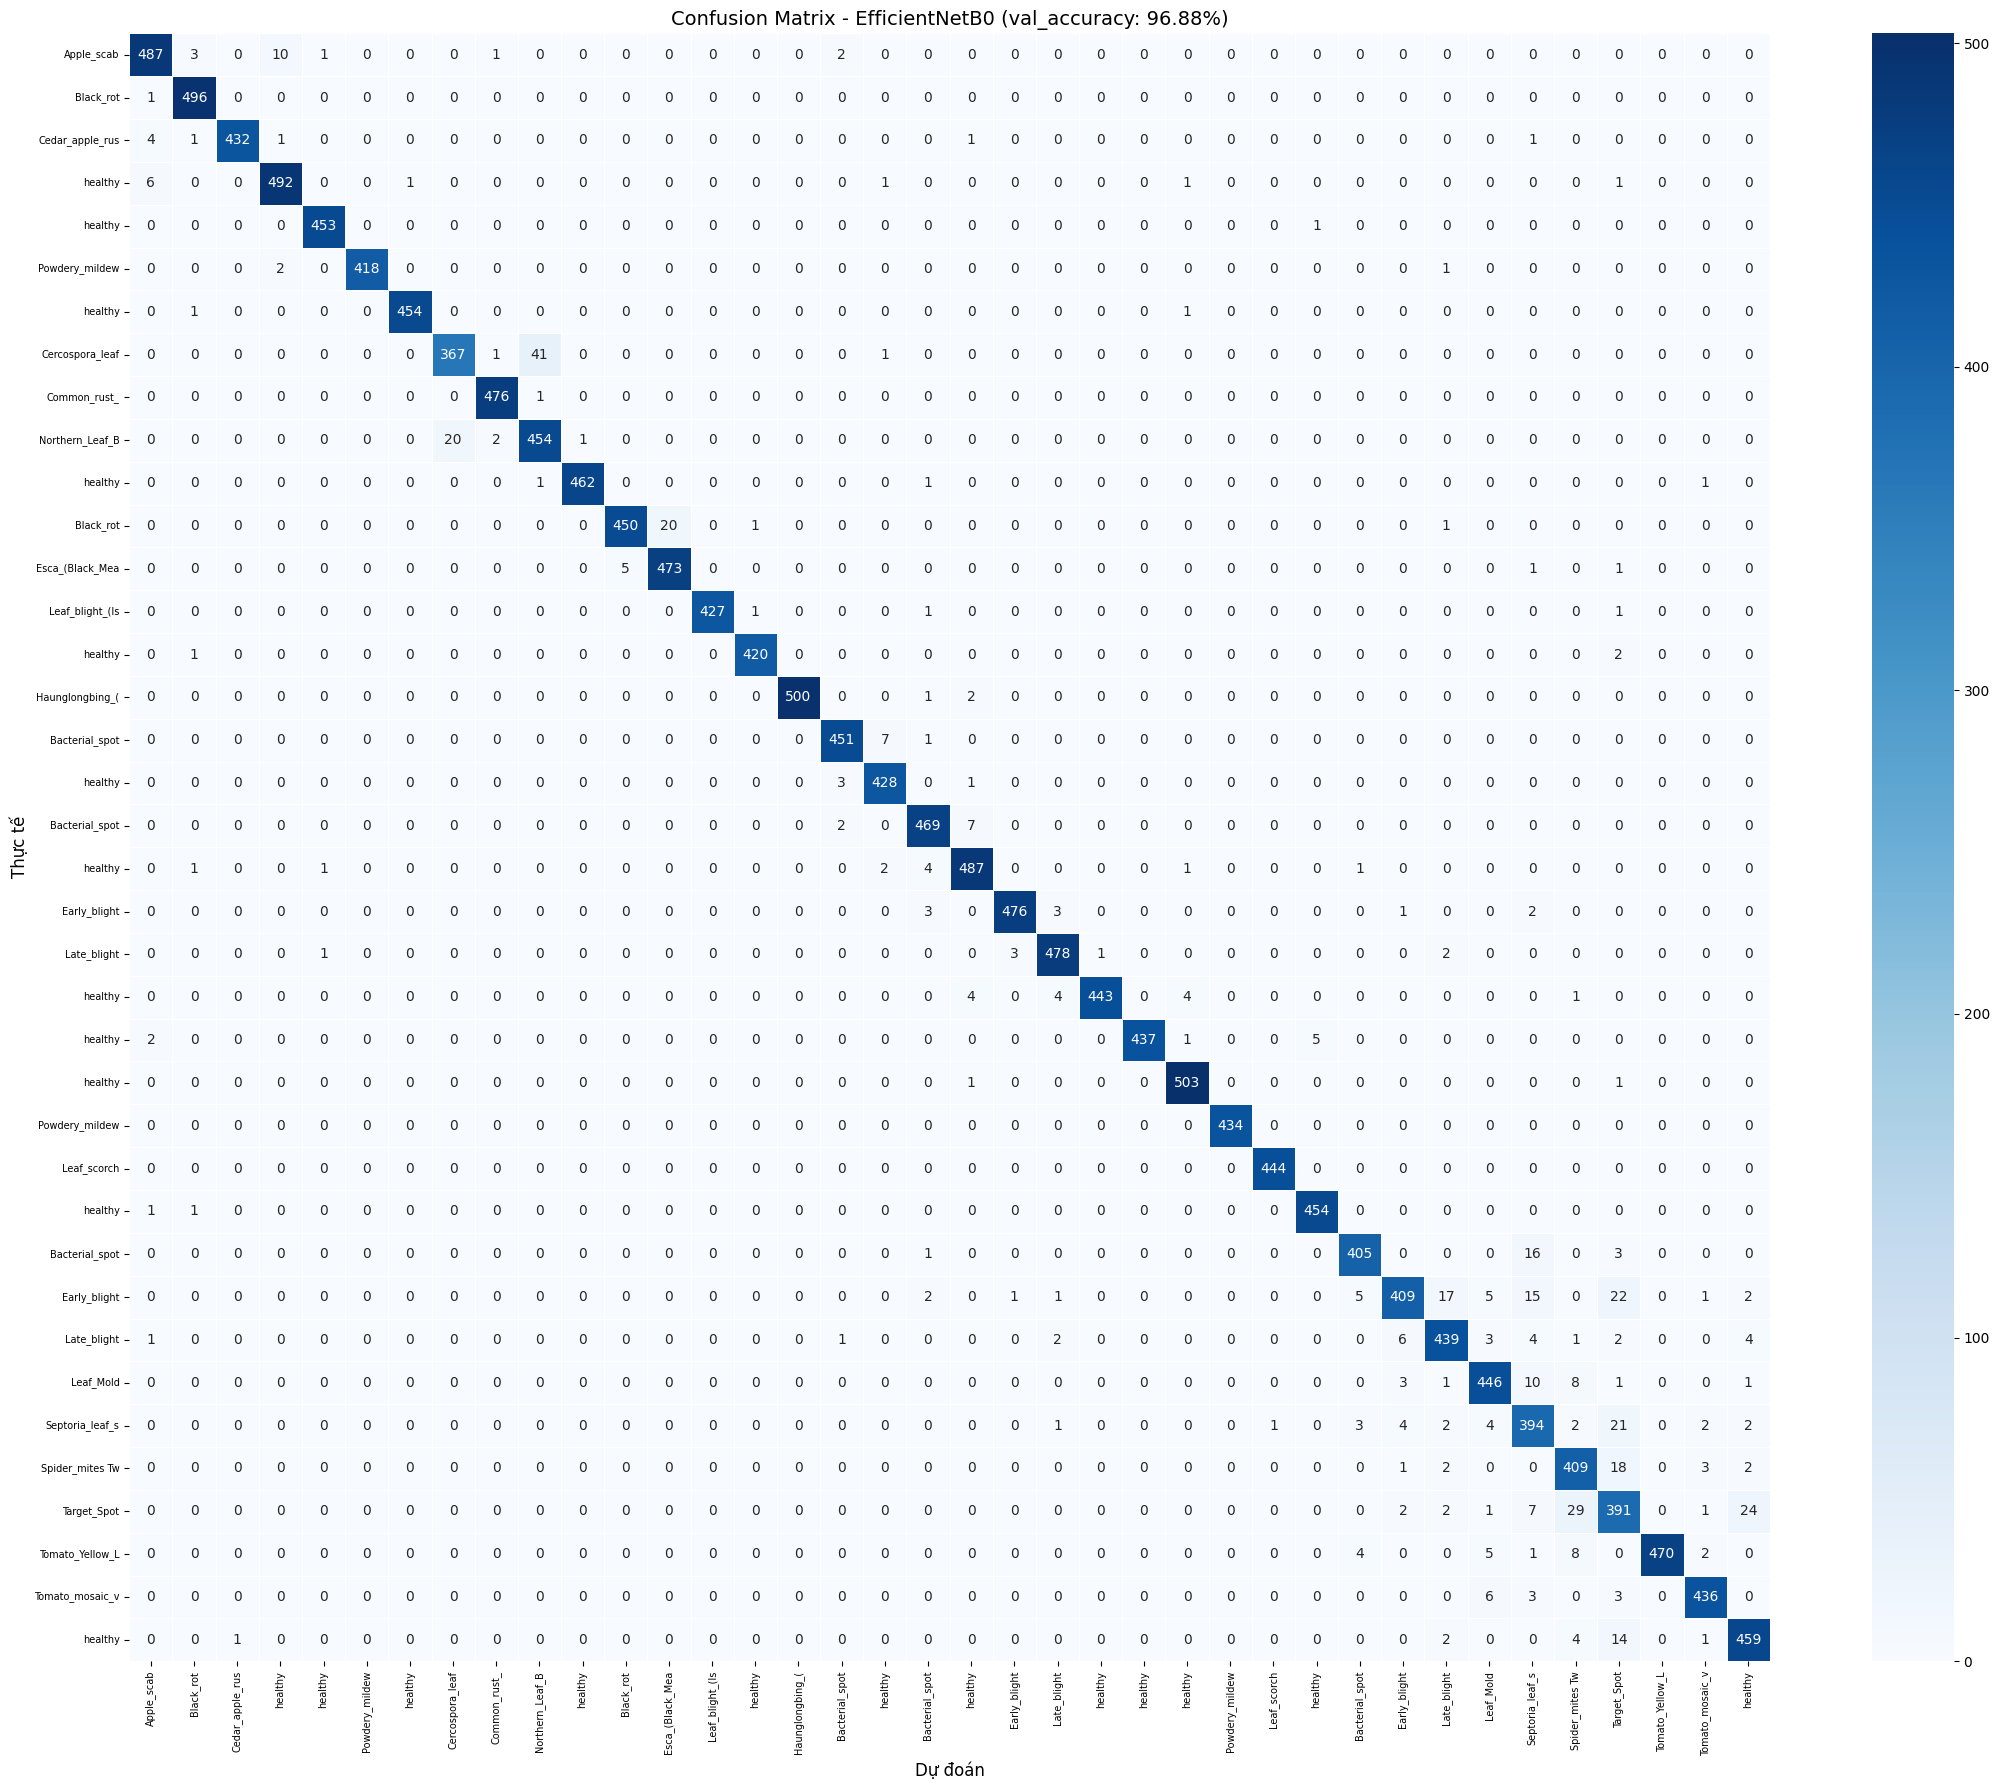

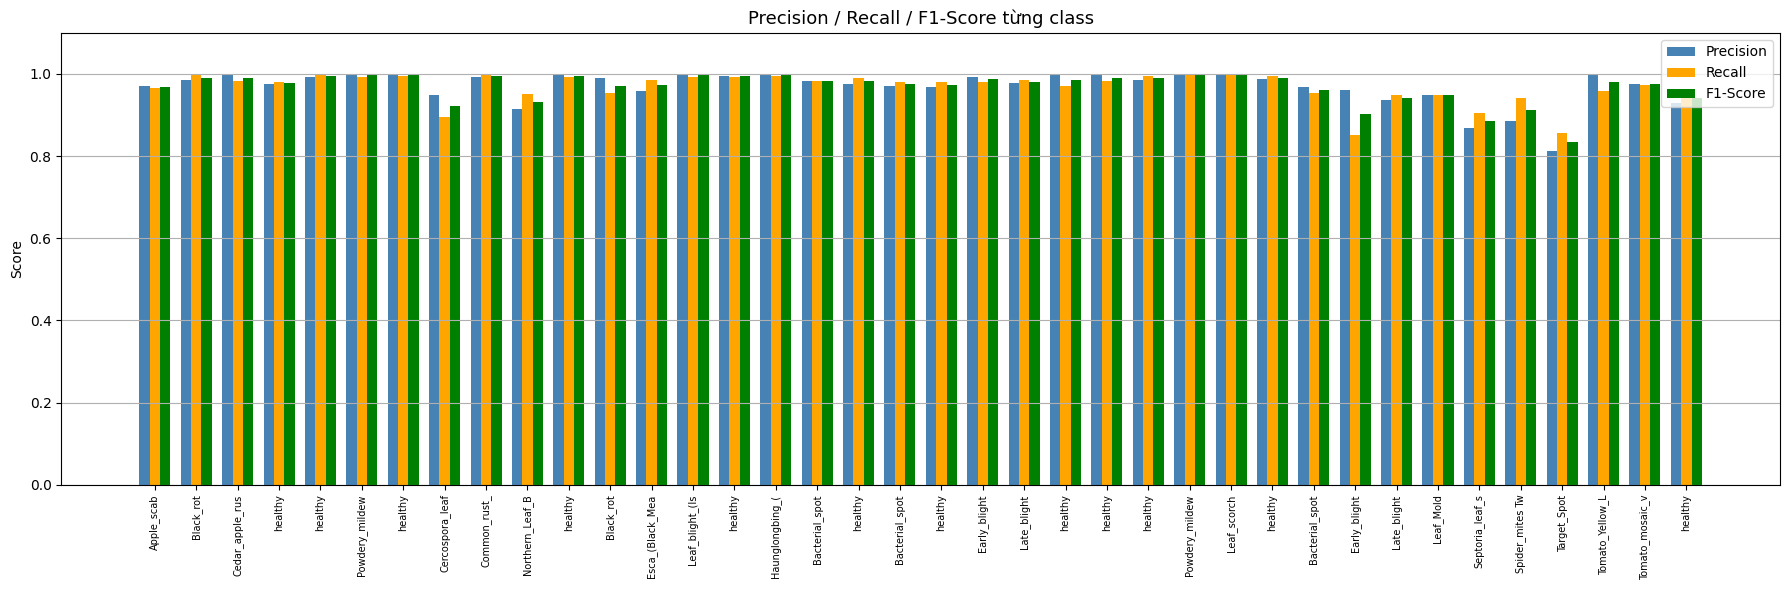


Tổng thể:
Accuracy: 96.88%
Precision TB: 96.92%
Recall TB: 96.85%
F1-Score TB: 96.87%


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load lại valid generator với shuffle=False
valid_datagen2 = ImageDataGenerator()
valid_generator2 = valid_datagen2.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Đang dự đoán...")
y_pred = model.predict(valid_generator2, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = valid_generator2.classes
class_names = list(valid_generator2.class_indices.keys())
short_names = [c.split('___')[-1][:15] for c in class_names]

print(f"Accuracy: {np.mean(y_true == y_pred_classes)*100:.2f}%")

# Biểu đồ 3 - Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names,
            linewidths=0.5)
plt.title('Confusion Matrix - EfficientNetB0 (val_accuracy: 96.88%)', fontsize=14)
plt.ylabel('Thực tế', fontsize=12)
plt.xlabel('Dự đoán', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{output_dir}/confusion_matrix.png', dpi=150)
plt.show()

# Biểu đồ 4 - F1 Score từng class
precision = precision_score(y_true, y_pred_classes, average=None)
recall = recall_score(y_true, y_pred_classes, average=None)
f1 = f1_score(y_true, y_pred_classes, average=None)

x = range(len(class_names))
fig, ax = plt.subplots(figsize=(18, 6))
width = 0.25
ax.bar([i - width for i in x], precision, width, label='Precision', color='steelblue')
ax.bar([i for i in x], recall, width, label='Recall', color='orange')
ax.bar([i + width for i in x], f1, width, label='F1-Score', color='green')

ax.set_xticks(list(x))
ax.set_xticklabels(short_names, rotation=90, fontsize=7)
ax.set_title('Precision / Recall / F1-Score từng class', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(f'{output_dir}/metrics_per_class.png', dpi=150)
plt.show()

print(f"\nTổng thể:")
print(f"Accuracy: {np.mean(y_true == y_pred_classes)*100:.2f}%")
print(f"Precision TB: {np.mean(precision)*100:.2f}%")
print(f"Recall TB: {np.mean(recall)*100:.2f}%")
print(f"F1-Score TB: {np.mean(f1)*100:.2f}%")